In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import random

DATASET_PATH = r"Novi Dataset\patches_8000_fps"
MODEL_SAVE_PATH = "SavedModels"
MODEL_NAME = "PatchesFPS8000_PointNet_BatchSize16.pth"
EPOCHS = 100
PATIENCE = 10
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
BATCH_SIZE = 16

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Training PointNet on FPS PATCHES on: {DEVICE}")
print(f"Dataset: {DATASET_PATH} | Seed: {SEED}")

Training PointNet on FPS PATCHES on: cuda
Dataset: Novi Dataset\patches_8000_fps | Seed: 42


In [2]:
class PatchDataset(Dataset):
    """
    Ucitava jedan patch (tocno 8000 tocaka). Boje 0-255 -> 0-1. Augmentacija opcionalno.
    Svi patchevi su iste velicine pa nema paddinga.
    """
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()

        points = data['points'].astype(np.float32)
        colors = data['colors'].astype(np.float32)
        labels = data['labels'].astype(np.int64)

        if colors.max() > 1.0:
            colors = colors / 255.0

        if self.augment:
            angle = np.random.uniform(0, 2 * np.pi)
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            rot = np.array([[cos_a, -sin_a, 0],
                            [sin_a,  cos_a, 0],
                            [0,      0,     1]], dtype=np.float32)
            points = points @ rot.T
            points += np.random.randn(*points.shape).astype(np.float32) * 0.005

        features = np.concatenate([points, colors], axis=1)

        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
            file_path
        )

In [3]:
class TNet(nn.Module):
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv1d(k, 64, 1),    nn.BatchNorm1d(64),   nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1),  nn.BatchNorm1d(128),  nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1),nn.BatchNorm1d(1024), nn.ReLU())
        self.fc1   = nn.Sequential(nn.Linear(1024, 512),   nn.BatchNorm1d(512),  nn.ReLU())
        self.fc2   = nn.Sequential(nn.Linear(512, 256),    nn.BatchNorm1d(256),  nn.ReLU())
        self.fc3   = nn.Linear(256, k * k)

        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)
        with torch.no_grad():
            self.fc3.bias.copy_(torch.eye(k).flatten())

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.max(dim=-1)[0]
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x.view(-1, self.k, self.k)


class PointNetRGBSegmentation(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.num_classes = num_classes

        self.tnet3  = TNet(k=3)
        self.conv1  = nn.Sequential(nn.Conv1d(6, 64, 1),    nn.BatchNorm1d(64),   nn.ReLU())
        self.conv2  = nn.Sequential(nn.Conv1d(64, 64, 1),   nn.BatchNorm1d(64),   nn.ReLU())
        self.tnet64 = TNet(k=64)
        self.conv3  = nn.Sequential(nn.Conv1d(64, 64, 1),   nn.BatchNorm1d(64),   nn.ReLU())
        self.conv4  = nn.Sequential(nn.Conv1d(64, 128, 1),  nn.BatchNorm1d(128),  nn.ReLU())
        self.conv5  = nn.Sequential(nn.Conv1d(128, 1024, 1),nn.BatchNorm1d(1024), nn.ReLU())

        self.seg_conv1 = nn.Sequential(nn.Conv1d(1024 + 64, 512, 1), nn.BatchNorm1d(512), nn.ReLU())
        self.seg_conv2 = nn.Sequential(nn.Conv1d(512, 256, 1),       nn.BatchNorm1d(256), nn.ReLU())
        self.seg_conv3 = nn.Sequential(nn.Conv1d(256, 128, 1),       nn.BatchNorm1d(128), nn.ReLU())
        self.seg_conv4 = nn.Sequential(nn.Conv1d(128, 64, 1),        nn.BatchNorm1d(64),  nn.ReLU())
        self.drop      = nn.Dropout(0.5)
        self.seg_conv5 = nn.Conv1d(64, num_classes, 1)

    def forward(self, xyzrgb):
        B, N, _ = xyzrgb.shape

        xyz = xyzrgb[:, :, :3].permute(0, 2, 1)
        x   = xyzrgb.permute(0, 2, 1)

        t3    = self.tnet3(xyz)
        xyz_t = torch.bmm(t3, xyz)
        x     = torch.cat([xyz_t, x[:, 3:, :]], dim=1)

        x = self.conv1(x)
        x = self.conv2(x)

        t64 = self.tnet64(x)
        x   = torch.bmm(t64, x)
        local_feat = x

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        global_feat = x.max(dim=-1)[0].unsqueeze(-1).expand(B, 1024, N)
        x = torch.cat([global_feat, local_feat], dim=1)

        x = self.seg_conv1(x)
        x = self.seg_conv2(x)
        x = self.seg_conv3(x)
        x = self.seg_conv4(x)
        x = self.drop(x)
        x = self.seg_conv5(x)
        return x

In [4]:
patch_pattern = os.path.join(DATASET_PATH, "tree_*", "*", "*.npy")
all_patch_files = glob.glob(patch_pattern)
print(f"Ukupno patcheva: {len(all_patch_files)}")

def get_tree_name(fp):
    return fp.split(os.sep)[-3]

unique_trees = sorted(list(set(get_tree_name(f) for f in all_patch_files)))
print(f"Ukupno stabala: {len(unique_trees)}")

train_trees, test_trees = train_test_split(unique_trees, test_size=0.15, random_state=42)
train_trees, val_trees  = train_test_split(train_trees,  test_size=0.18, random_state=42)
train_trees, val_trees, test_trees = set(train_trees), set(val_trees), set(test_trees)

train_paths = [f for f in all_patch_files if get_tree_name(f) in train_trees]
val_paths   = [f for f in all_patch_files if get_tree_name(f) in val_trees]
test_paths  = [f for f in all_patch_files if get_tree_name(f) in test_trees]

train_dataset = PatchDataset(train_paths, augment=True)
val_dataset   = PatchDataset(val_paths,   augment=False)
test_dataset  = PatchDataset(test_paths,  augment=False)

generator_treninga = torch.Generator()
generator_treninga.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=generator_treninga)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0)

print(f"Train patcheva: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
print(f"Train stabala: {len(train_trees)} | Val: {len(val_trees)} | Test: {len(test_trees)}")

Ukupno patcheva: 8107
Ukupno stabala: 58
Train patcheva: 5460 | Val: 1491 | Test: 1156
Train stabala: 40 | Val: 9 | Test: 9


Ucestalost klasa: {0: 4875525, 1: 26655800, 2: 5439154, 3: 6709521}
Auto alpha: ['2.240', '0.410', '2.008', '1.628']


Epoch 1/100: 100%|██████████| 342/342 [02:00<00:00,  2.85it/s, Loss=0.3952]


Epoch [1/100] -> Loss: 0.4623, Train Acc: 0.5602, Val Acc: 0.6019 | Time: 140.4s
--- Best model saved (Val Acc: 0.6019) ---


Epoch 2/100: 100%|██████████| 342/342 [02:00<00:00,  2.84it/s, Loss=0.3576]


Epoch [2/100] -> Loss: 0.3978, Train Acc: 0.6276, Val Acc: 0.6904 | Time: 131.1s
--- Best model saved (Val Acc: 0.6904) ---


...

Epoch [98/100] -> Loss: 0.0724, Train Acc: 0.9644, Val Acc: 0.9126 | Time: 113.1s
--- No improvement: 5/10 ---


Epoch 99/100: 100%|██████████| 342/342 [01:43<00:00,  3.31it/s, Loss=0.4739]


Epoch [99/100] -> Loss: 0.0720, Train Acc: 0.9637, Val Acc: 0.9179 | Time: 112.5s
--- No improvement: 6/10 ---


Epoch 100/100: 100%|██████████| 342/342 [01:43<00:00,  3.31it/s, Loss=0.0769]


Epoch [100/100] -> Loss: 0.0668, Train Acc: 0.9664, Val Acc: 0.9231 | Time: 112.7s
--- Best model saved (Val Acc: 0.9231) ---

Ukupno vrijeme treninga: 03:09:37


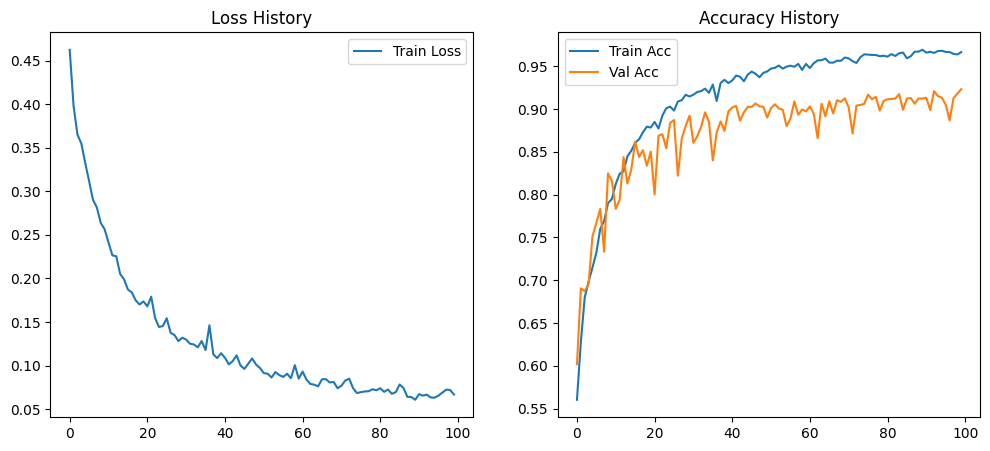

In [5]:
set_seed(SEED)

model = PointNetRGBSegmentation(num_classes=4).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([float(alpha)] * NUM_CLASSES)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            at = alpha[targets]
            focal_loss = at * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.0
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == 'present' and fg.sum() == 0:
            continue
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    if len(losses) == 0:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

class LovaszSoftmaxLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, inputs, targets):
        probas = F.softmax(inputs, dim=1)
        B, C, N = probas.shape
        probas = probas.permute(0, 2, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return lovasz_softmax_flat(probas, targets)


from collections import Counter
brojac = Counter()
for fp in train_paths:
    d = np.load(fp, allow_pickle=True).item()
    lbls = np.array(d['labels'], dtype=np.int64)
    for c in range(NUM_CLASSES):
        brojac[c] += int(np.sum(lbls == c))

ukupno = sum(brojac.values())
alpha_auto = [ukupno / (NUM_CLASSES * brojac[c]) if brojac[c] > 0 else 0.0 for c in range(NUM_CLASSES)]
print("Ucestalost klasa:", dict(brojac))
print("Auto alpha:", [f"{a:.3f}" for a in alpha_auto])

criterion = FocalLoss(alpha=alpha_auto, gamma=2.0)
lovasz = LovaszSoftmaxLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0
patience = PATIENCE
epochs_no_improve = 0

training_start = time.time()

try:
    for epoch in range(EPOCHS):
        epoch_start = time.time()
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for features, labels, _ in pbar:
            features, labels = features.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(features)
            loss = 0.5 * criterion(outputs, labels) + 0.5 * lovasz(outputs, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for features, labels, _ in val_loader:
                features, labels = features.to(DEVICE), labels.to(DEVICE)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_acc = val_correct / val_total if val_total > 0 else 0
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, MODEL_NAME))
            print(f"--- Best model saved (Val Acc: {val_acc:.4f}) ---")
        else:
            epochs_no_improve += 1
            print(f"--- No improvement: {epochs_no_improve}/{patience} ---")
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs. Best Val Acc: {best_val_acc:.4f}")
                break

except KeyboardInterrupt:
    print(f"\nTrening prekinut. Najbolji Val Acc: {best_val_acc:.4f}")

total_time = time.time() - training_start
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nUkupno vrijeme treninga: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss History')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [6]:
import open3d as o3d
import time
from collections import defaultdict

MODEL_PATH = os.path.join("SavedModels", "PatchesFPS8000_PointNet_BatchSize16.pth")

model = PointNetRGBSegmentation(num_classes=4).to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    print(f"Model loaded from: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")
model.eval()

KLASE = {0: "deblo", 1: "grane", 2: "potpora", 3: "trava"}


def predict_logits(model, features, device):
    x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)
    return out.squeeze(0).permute(1, 0).cpu().numpy()


oblaci = defaultdict(list)
for fp in test_paths:
    tree = fp.split(os.sep)[-3]
    cloud = fp.split(os.sep)[-2]
    oblaci[(tree, cloud)].append(fp)

print(f"Test oblaka: {len(oblaci)}")

conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
oblak_rezultati = []
inference_times = []

for (tree, cloud), patch_files in tqdm(oblaci.items(), desc="Rekonstrukcija po oblaku"):
    p0 = np.load(patch_files[0], allow_pickle=True).item()
    N = int(p0['n_original'])

    logit_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    logit_cnt = np.zeros(N, dtype=np.int64)
    prave_lbl = np.full(N, -1, dtype=np.int64)
    orig_points = np.zeros((N, 3), dtype=np.float64)
    orig_colors = np.zeros((N, 3), dtype=np.float64)

    t0 = time.perf_counter()
    for fp in patch_files:
        p = np.load(fp, allow_pickle=True).item()
        oi = p['orig_idx']
        points = p['points'].astype(np.float32)
        colors = p['colors'].astype(np.float32)
        cols_norm = colors / 255.0 if colors.max() > 1.0 else colors

        features = np.concatenate([points, cols_norm], axis=1)
        logits = predict_logits(model, features, DEVICE)

        logit_sum[oi] += logits
        logit_cnt[oi] += 1
        prave_lbl[oi] = p['labels']
        orig_points[oi] = points
        orig_colors[oi] = cols_norm
    inference_times.append(time.perf_counter() - t0)

    valid = logit_cnt > 0
    logit_avg = logit_sum[valid] / logit_cnt[valid, None]
    pred = np.argmax(logit_avg, axis=1)
    prave = prave_lbl[valid]

    for t, pr in zip(prave, pred):
        conf[t, pr] += 1

    ious = []
    for c in range(NUM_CLASSES):
        tp = np.sum((pred == c) & (prave == c))
        fp_ = np.sum((pred == c) & (prave != c))
        fn = np.sum((pred != c) & (prave == c))
        if np.sum(prave == c) > 0:
            ious.append(tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 1.0)
    miou = np.mean(ious) if ious else 0.0

    oblak_rezultati.append({
        'tree': tree, 'cloud': cloud, 'miou': miou,
        'points': orig_points[valid], 'colors': orig_colors[valid],
        'labels': prave, 'preds': pred,
        'pokriveno': int(valid.sum()), 'ukupno': N
    })

total_points = conf.sum()
accuracy = np.trace(conf) / total_points if total_points > 0 else 0

per_class_iou, per_class_prec, per_class_rec = {}, {}, {}
for c in range(NUM_CLASSES):
    tp = conf[c, c]
    fp_ = conf[:, c].sum() - tp
    fn = conf[c, :].sum() - tp
    per_class_iou[c]  = tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 0
    per_class_prec[c] = tp / (tp + fp_) if (tp + fp_) > 0 else 0
    per_class_rec[c]  = tp / (tp + fn) if (tp + fn) > 0 else 0
mean_iou = np.mean(list(per_class_iou.values()))

print("\n" + "="*50)
print("FINAL TEST METRICS: FPS PATCHES PointNet (rekonstruirano stablo)")
print("="*50)
print(f"Total Points: {total_points:,}")
print(f"Accuracy: {accuracy:.4f}")
print("-"*50)
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10} | IoU: {per_class_iou[c]:.4f} | Prec: {per_class_prec[c]:.4f} | Recall: {per_class_rec[c]:.4f}")
print("-"*50)
print(f"mIoU: {mean_iou:.4f}")
print("="*50)

print("\nConfusion [redak=stvarno, stupac=predvidjeno]:")
print(f"{'':<10}" + "".join(f"{KLASE[c]:<10}" for c in range(NUM_CLASSES)))
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10}" + "".join(f"{conf[c, p]:<10}" for p in range(NUM_CLASSES)))

svi_pokriveni = all(r['pokriveno'] == r['ukupno'] for r in oblak_rezultati)
print(f"\nRekonstrukcija egzaktna (sve tocke pokrivene)? {'DA' if svi_pokriveni else 'NE'}")
avg_inf = np.mean(inference_times)
print(f"Prosjecno vrijeme po stablu: {avg_inf:.3f}s")
print("="*50)

PALETTE = {0: [0.0, 0.0, 1.0], 1: [0.0, 0.8, 0.0], 2: [1.0, 0.0, 0.0], 3: [0.6, 0.6, 0.6]}

def boji_po_klasi(labels):
    c = np.zeros((len(labels), 3))
    for k, col in PALETTE.items():
        c[labels == k] = col
    return c

oblak_rezultati.sort(key=lambda x: x['miou'])
worst = oblak_rezultati[0]
best  = oblak_rezultati[-1]

for tag, rez in [("WORST", worst), ("BEST", best)]:
    print(f"\n[{tag}] {rez['tree']}/{rez['cloud']} | mIoU: {rez['miou']:.4f}")
    pts = rez['points']
    for col, naslov in [(rez['colors'], "ORIGINAL RGB"),
                        (boji_po_klasi(rez['labels']), "LABELE"),
                        (boji_po_klasi(rez['preds']), "PREDIKCIJA")]:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.colors = o3d.utility.Vector3dVector(col)
        o3d.visualization.draw_geometries([pcd], window_name=f"{tag} {naslov} | {rez['tree']} | mIoU {rez['miou']:.3f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Model loaded from: SavedModels\PatchesFPS8000_PointNet_BatchSize16.pth
Test oblaka: 92


Rekonstrukcija po oblaku: 100%|██████████| 92/92 [00:25<00:00,  3.59it/s]



FINAL TEST METRICS: FPS PATCHES PointNet (rekonstruirano stablo)
Total Points: 8,865,711
Accuracy: 0.9237
--------------------------------------------------
deblo      | IoU: 0.5328 | Prec: 0.7761 | Recall: 0.6295
grane      | IoU: 0.8946 | Prec: 0.9220 | Recall: 0.9680
potpora    | IoU: 0.7388 | Prec: 0.9360 | Recall: 0.7781
trava      | IoU: 0.9998 | Prec: 0.9998 | Recall: 1.0000
--------------------------------------------------
mIoU: 0.7915

Confusion [redak=stvarno, stupac=predvidjeno]:
          deblo     grane     potpora   trava     
deblo     580182    336173    5246      15        
grane     154173    5585148   30745     1         
potpora   13227     136632    526258    221       
trava     0         6         1         1497683   

Rekonstrukcija egzaktna (sve tocke pokrivene)? DA
Prosjecno vrijeme po stablu: 0.207s

[WORST] tree_1_V_0056/3 | mIoU: 0.2588

[BEST] tree_1_V_0178/5 | mIoU: 0.9996
